# b. 2D Density Fluctuation Analysis in NaCl Solution
This notebook demonstrates how the physical density fluctuations ($\Delta\rho$) change as the salt concentration increases in a binary solution (NaCl in water).

## Data
We use open access data from following research work: 

> Abhishek Chattopadhyay, Varun Mandalaparthy, Nico F. A. van der Vegt; Determination of aqueous solubility of NaCl in molecular dynamics simulation using the Kirkwood–Buff method. J. Chem. Phys. 7 May 2025; 162 (17): 174116. https://doi.org/10.1063/5.0264104

Data Download Link : https://tudatalib.ulb.tu-darmstadt.de/items/d8fc198c-2db5-4b3d-8a42-7e527b25248a

We use the actual Radial Distribution Functions ($g(r)$) calculated from Molecular Dynamics trajectories at varying concentrations to compute the Kirkwood-Buff Integrals ($G_{ij}$) and reconstruct the true fluctuation covariance matrix ($\mathbf{S}$).

## Method
The theoretical foundation connecting the thermodynamic diffusion interaction parameter ($k_D$) and multicomponent density fluctuations via Kirkwood-Buff integrals is detailed in:
> Yang, J.; Brosz, M.; Adebar, N.; Burkert, O.; Schulze, M.; Smiatek, J. Influence of Co-Solutes and Solvents on Diffusion Interaction Parameters in Multicomponent Solutions: New Insights through the Kirkwood–Buff Theory. *J. Phys. Chem. B* **2025**, 129, 10381–10391. [doi:10.1021/acs.jpcb.5c03102](https://doi.org/10.1021/acs.jpcb.5c03102)

### How $\Delta\rho_1$ and $\Delta\rho_2$ are derived from the S-matrix

In the Grand Canonical Ensemble (where particle numbers can fluctuate), the covariance of particle number fluctuations $\langle \Delta N_i \Delta N_j \rangle$ is directly linked to the Kirkwood-Buff Integrals (KBI):
$$ \langle \Delta N_i \Delta N_j \rangle = V \cdot S_{ij} $$
$$ S_{ij} = \rho_i \delta_{ij} + \rho_i \rho_j G_{ij} $$
Since density fluctuation is defined as $\Delta\rho_i = \Delta N_i / V$, their covariance is given by:
$$ \langle \Delta\rho_i \Delta\rho_j \rangle = \frac{1}{V} S_{ij} $$
In the plots below, we visualize the fundamental shape of these fluctuations by drawing random samples from a 2D Multivariate Normal Distribution:
$$ (x, y) \sim \mathcal{N}\left(\mathbf{0}, \mathbf{S}\right) $$
Here, the x-axis represents the scaled solvent fluctuation ($\Delta\rho_1 \sqrt{V}$) and the y-axis represents the scaled solute fluctuation ($\Delta\rho_2 \sqrt{V}$). 
By performing an eigendecomposition (Principal Component Analysis) on this $\mathbf{S}$-matrix, we can extract its **eigenvalues** and **eigenvectors** to analyze the resulting **fluctuation ellipse**:
- The **eigenvectors** represent the principal axes of the density fluctuations, visually revealing the cross-correlation between water and salt (i.e., whether they fluctuate in-phase to form aggregates or out-of-phase due to exclusion).
- The **eigenvalues** quantify the variance of the fluctuations along these principal axes. 
The geometric properties of this ellipse (such as **Tilt Angle** and **Eccentricity**) provide direct visual and quantitative insights into preferential solvation, colloidal stability, and force-field specific clustering artifacts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from kb_fluct import read_xvg, calc_kbi, FluctuationMatrix, EllipseAnalyzer

force_fields = ['jc_ff', 'sd_ff', 'madrid_ff', 'ecc_ff', 'hmn3_ff']
#force_fields = ['jc_ff', 'sd_ff']

concs = np.arange(0.5, 8.0, 0.5)

for ff in force_fields:
    fig, axes = plt.subplots(3, 5, figsize=(25, 15))
    axes = axes.flatten()

    for i, conc in enumerate(concs):
        ax = axes[i]
        base_dir = f"../../data/solution_phase/{ff}/{conc}M_large_box/prod_npt/analysis"
        
        ww_files = glob.glob(f"{base_dir}/rdf/rdf_OW_OW*.xvg") + glob.glob(f"{base_dir}/rdf/rdf_water_water*.xvg")
        iw_files = glob.glob(f"{base_dir}/rdf/rdf_ion_water*.xvg")
        ii_files = glob.glob(f"{base_dir}/rdf/rdf_ion_ion*.xvg")
        vol_files = glob.glob(f"{base_dir}/avg_vol/avg_vol*.xvg")
        
        if not (ww_files and iw_files and ii_files and vol_files):
            ax.set_title(f"{conc} M NaCl")
            ax.set_xticks([]); ax.set_yticks([])
            continue
            
        try:
            r, g11_raw = read_xvg(ww_files[0])
            _, g12_raw = read_xvg(iw_files[0])
            _, g22_raw = read_xvg(ii_files[0])
            _, vol = read_xvg(vol_files[0])
        except Exception:
            continue
            
        avg_V = np.mean(vol)
        rho_1 = 1110.0 / avg_V
        rho_2 = (conc * 40.0) / avg_V
        
        G11 = calc_kbi(r, g11_raw)
        G12 = calc_kbi(r, g12_raw)
        G22 = calc_kbi(r, g22_raw)
        
        fluct = FluctuationMatrix(rho_1, rho_2).fit(G11, G22, G12)
        S_mat = fluct.results['S_matrix']
        analyzer = EllipseAnalyzer().fit(S_mat)
        
        # DRAW ARROWS UNCONDITIONALLY FIRST
        for j in range(2):
            vec = analyzer.results['eigenvectors'][:, j] * np.sqrt(np.abs(analyzer.results['eigenvalues'][j])) * 2
            ax.annotate("", xy=vec, xytext=(0, 0),
                        arrowprops=dict(facecolor="red", edgecolor="red", width=2, headwidth=8), zorder=5)
                        
        ax.set_title(f"{conc} M NaCl", fontsize=14)
        ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
        
        # DRAW POINTS
        np.random.seed(42)
        try:
            points = np.random.multivariate_normal([0, 0], S_mat, 50000)
            x, y = points[:, 0], points[:, 1]
            ax.scatter(x, y, s=1, color="blue", alpha=0.05)
        except ValueError:
            ax.set_title(f"{conc} M NaCl (Not PSD)", fontsize=14)

    plt.suptitle(f"Raw Density Fluctuations via kb_fluct ({ff.upper()})", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"fluctuation_raw_{ff}.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()



/var/folders/yr/nrlvkkq52sl8qmgymrl_yx040000gn/T/ipykernel_26776/2708422282.py:61: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points = np.random.multivariate_normal([0, 0], S_mat, 50000)


/var/folders/yr/nrlvkkq52sl8qmgymrl_yx040000gn/T/ipykernel_26776/3445437177.py:57: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points = np.random.multivariate_normal([0, 0], S_mat, 50000)


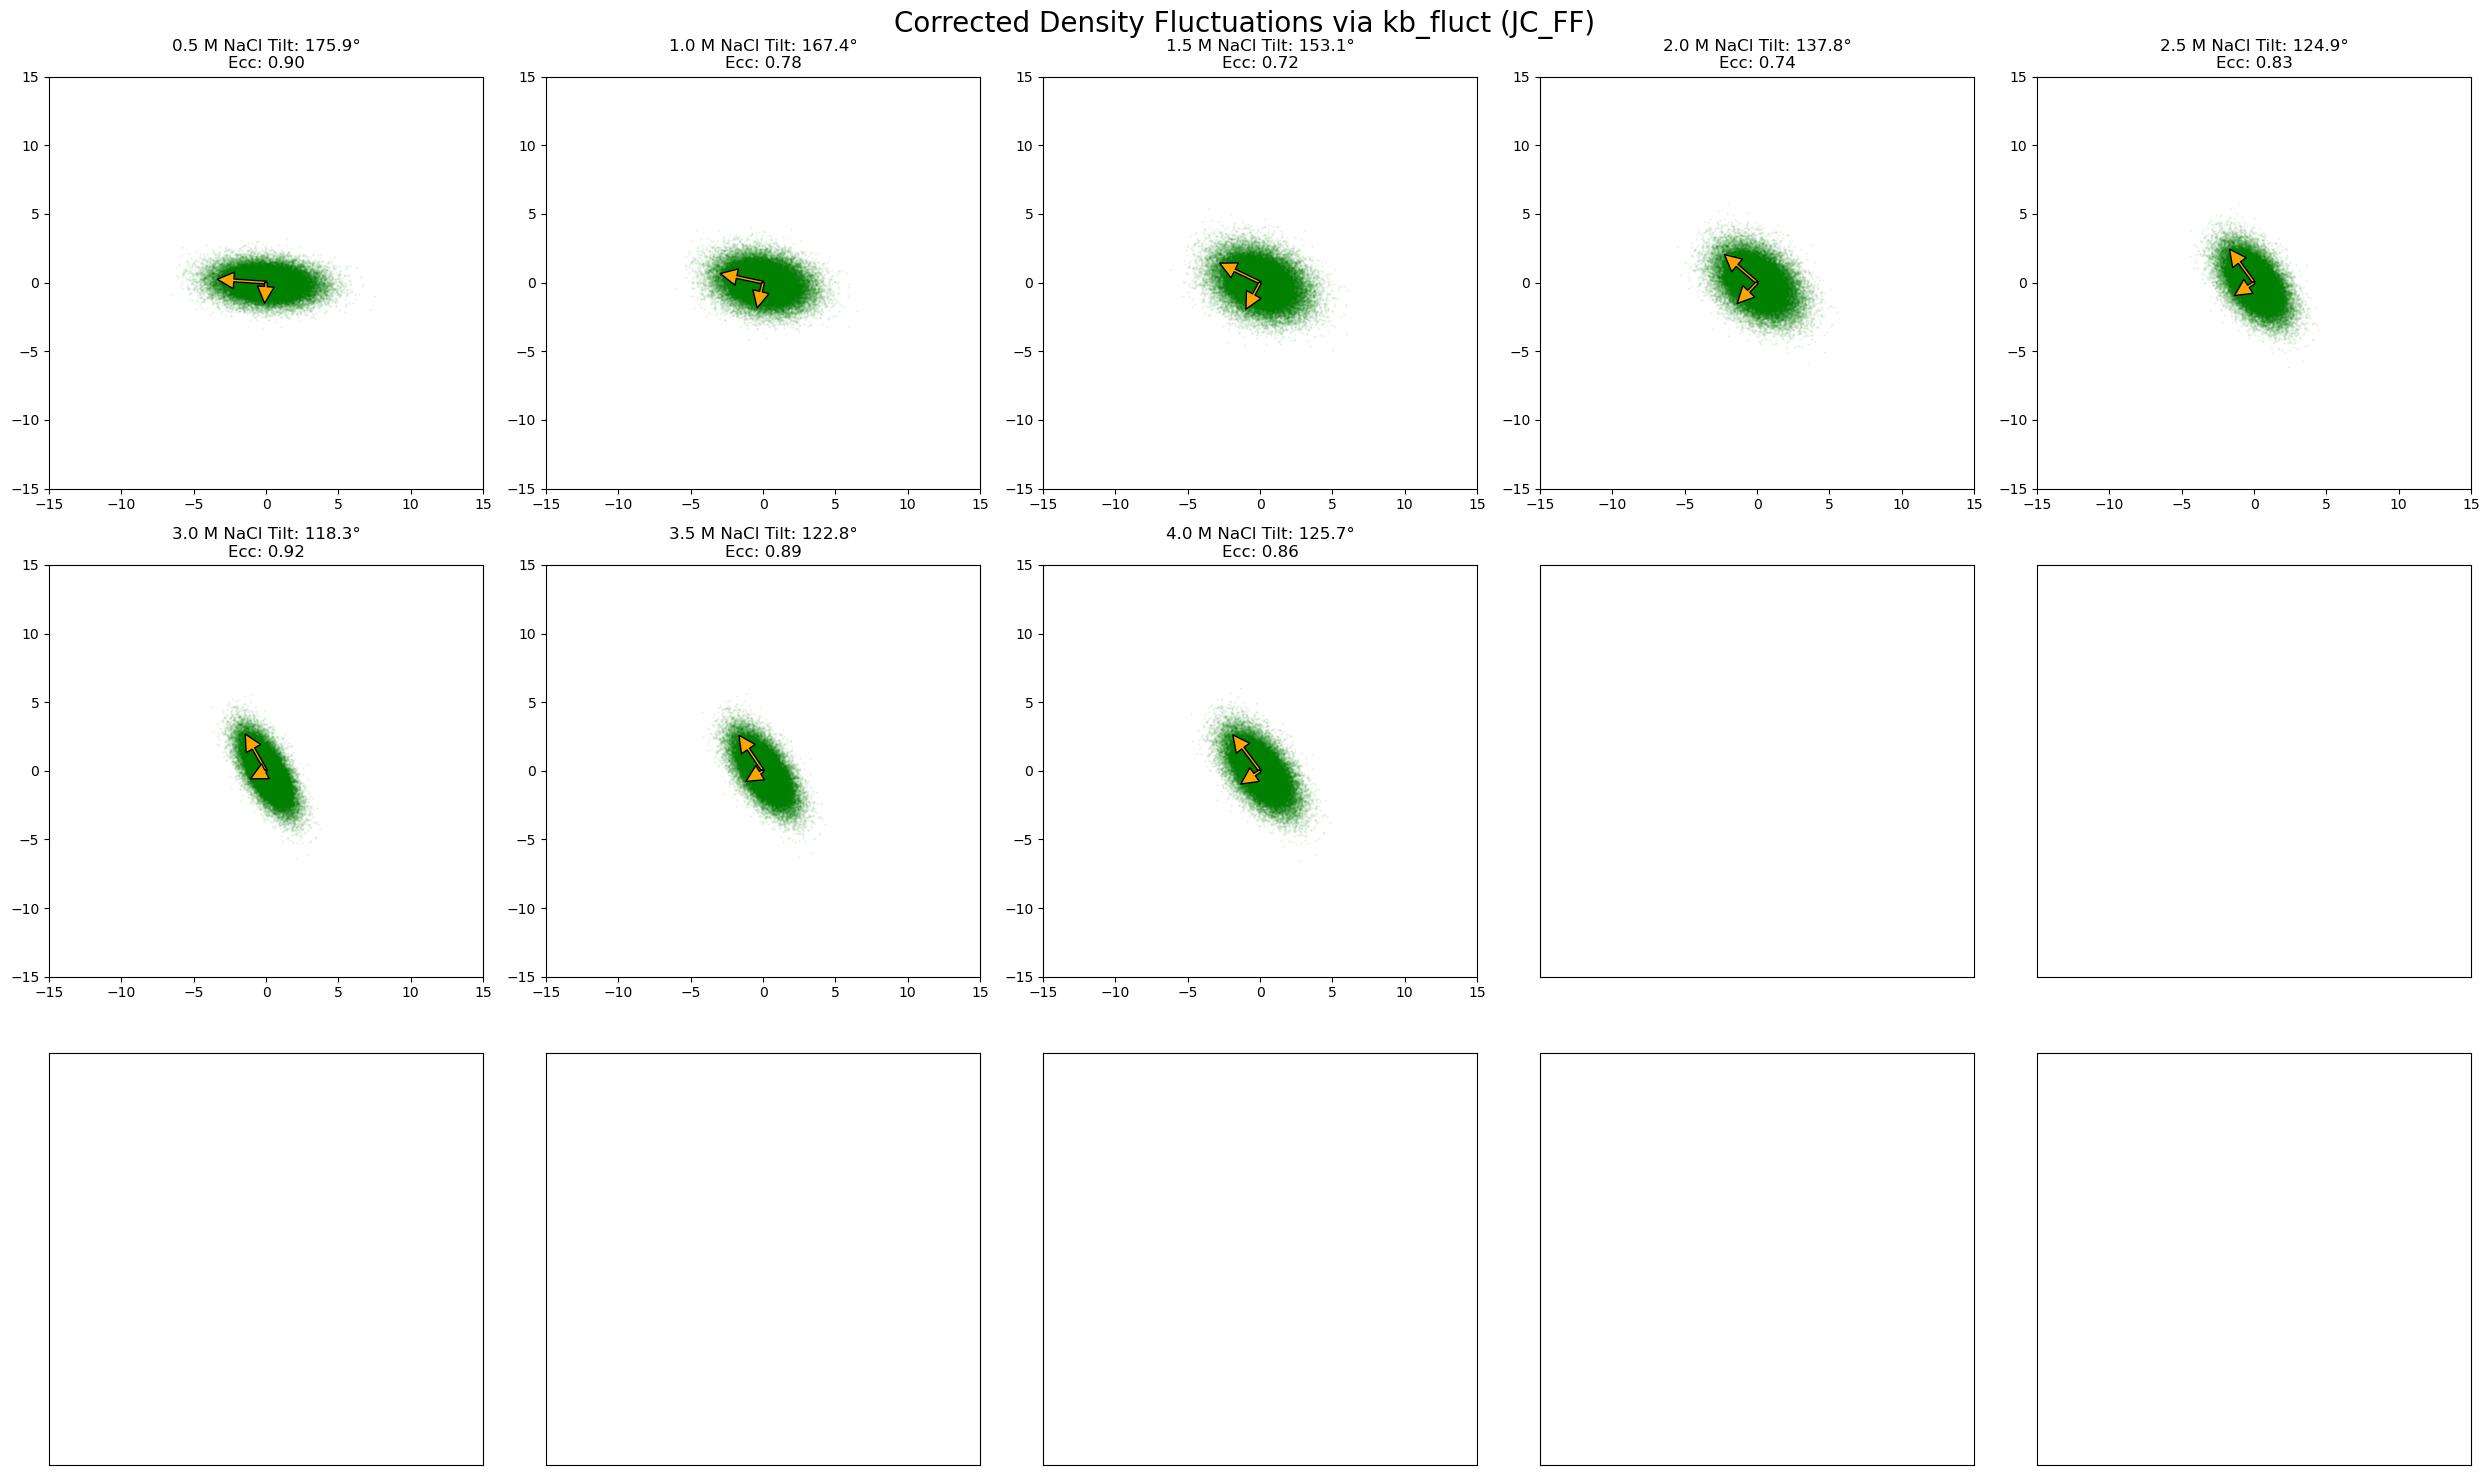

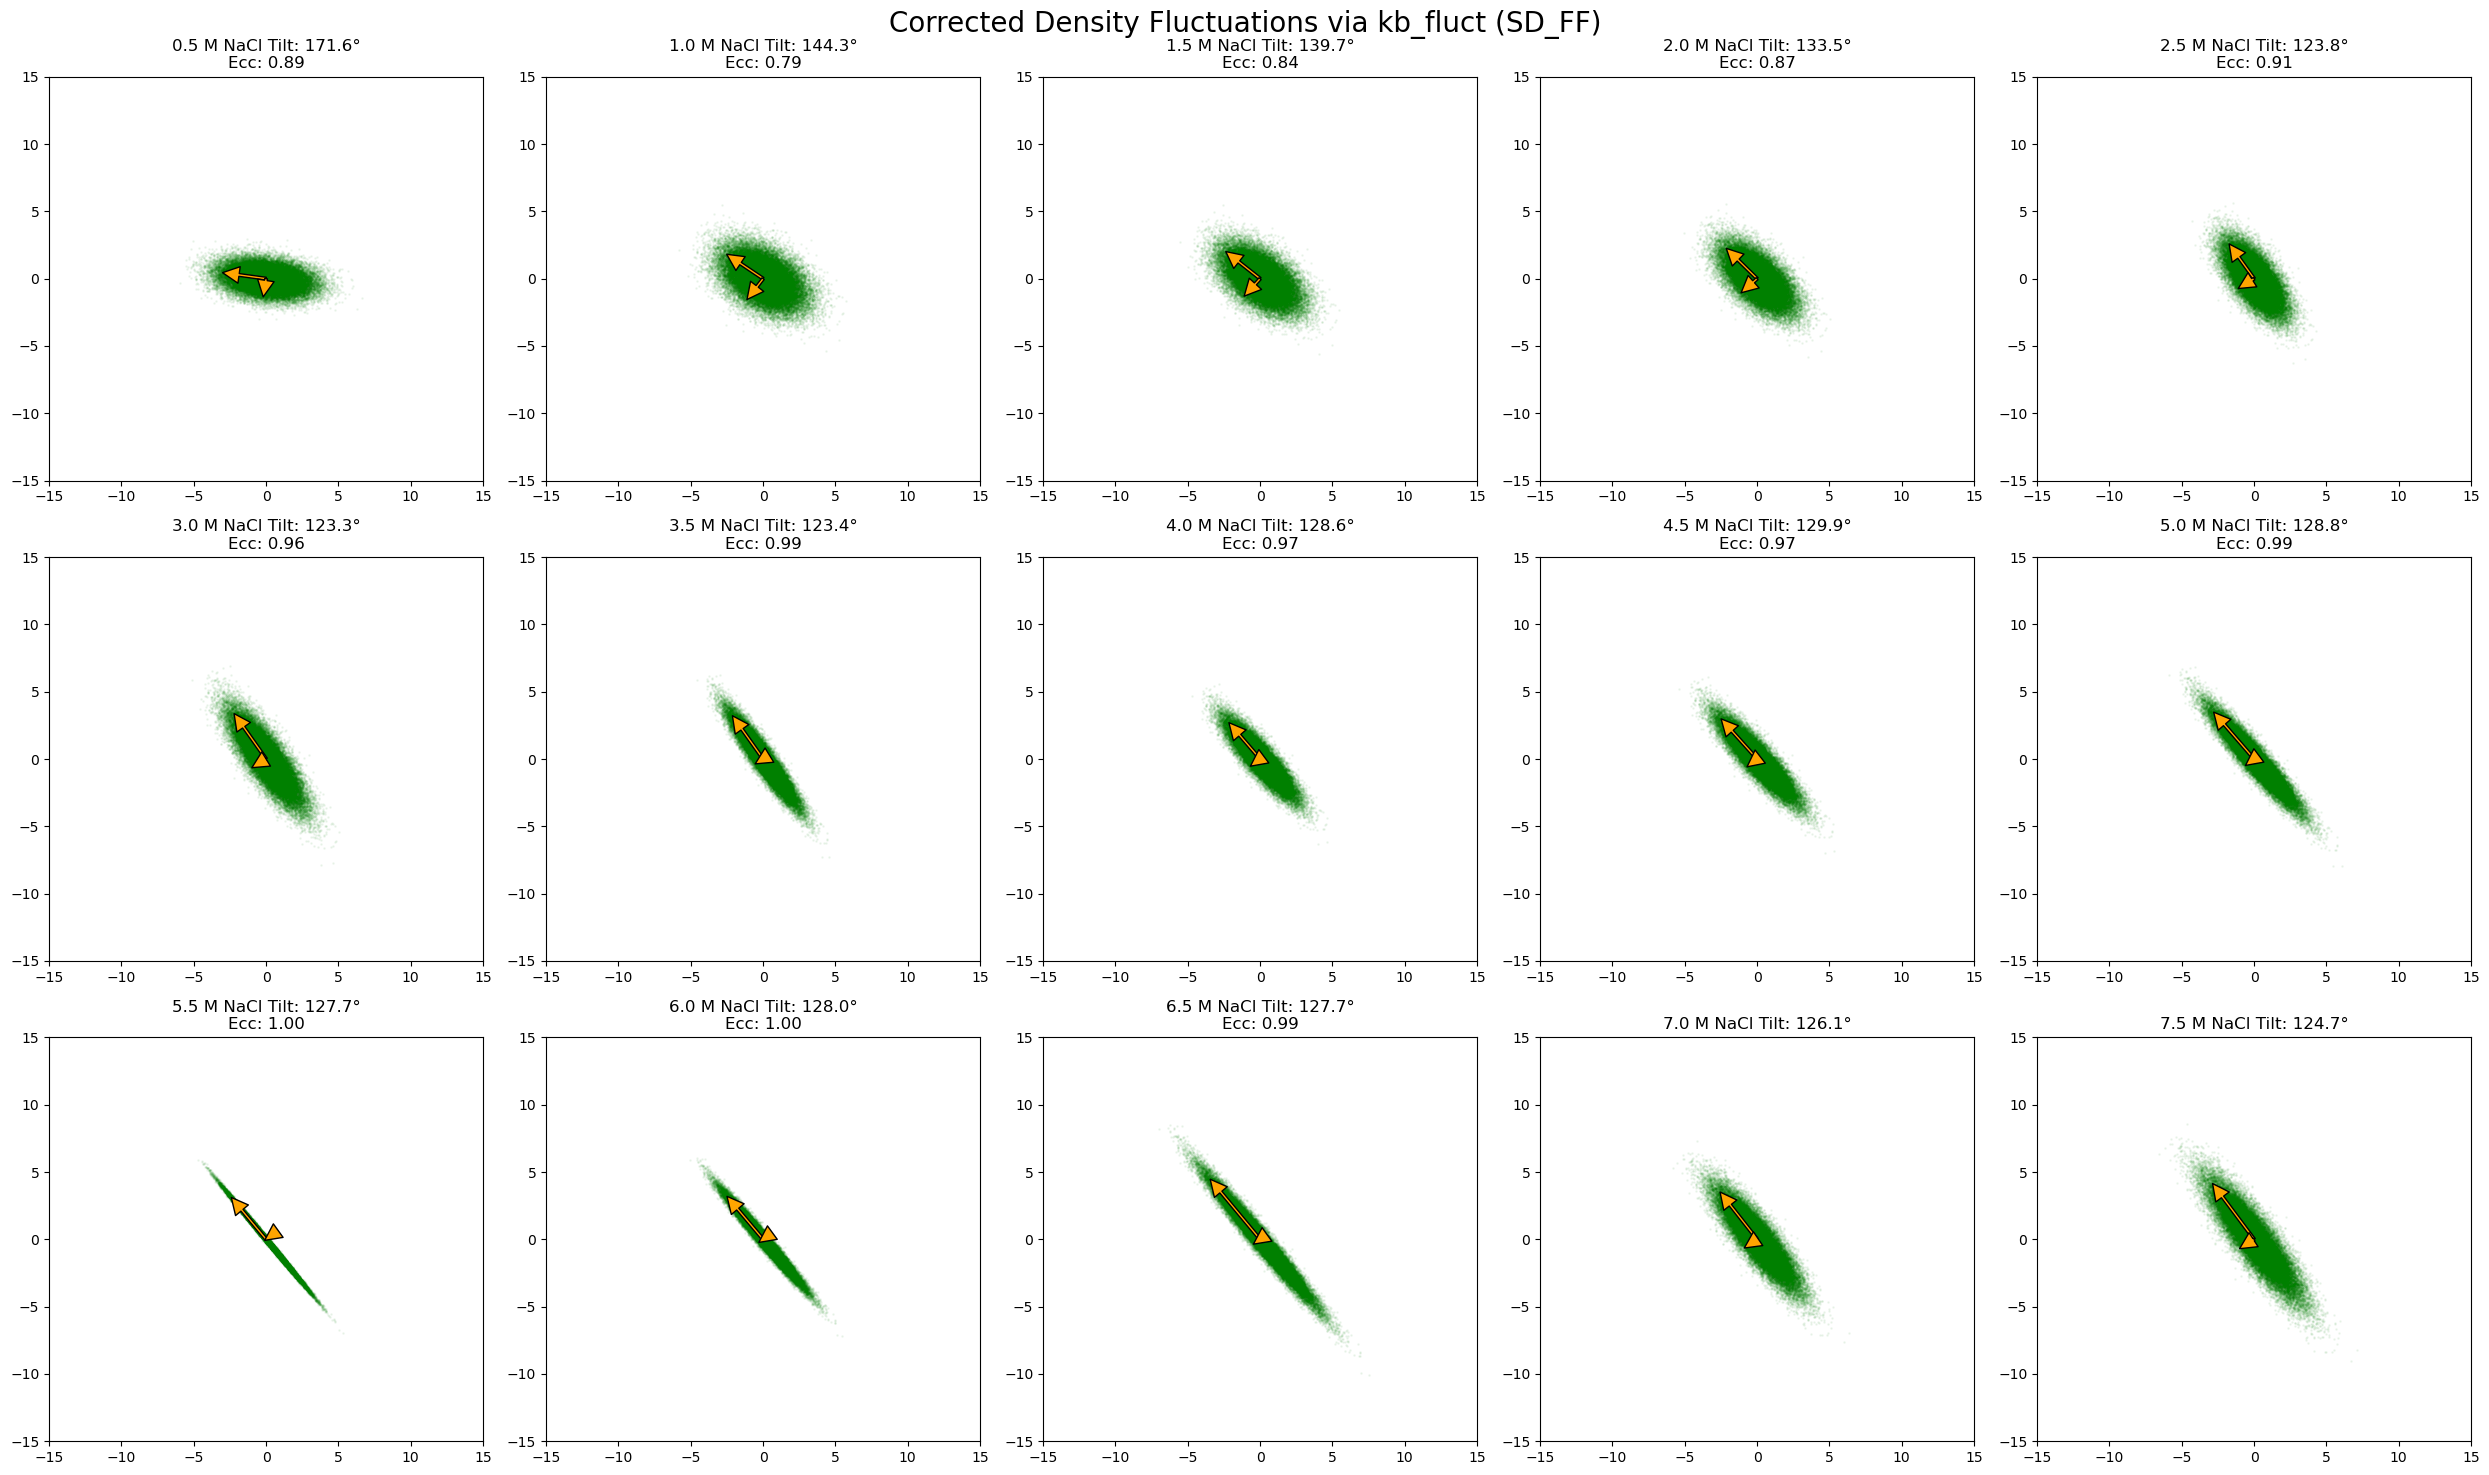

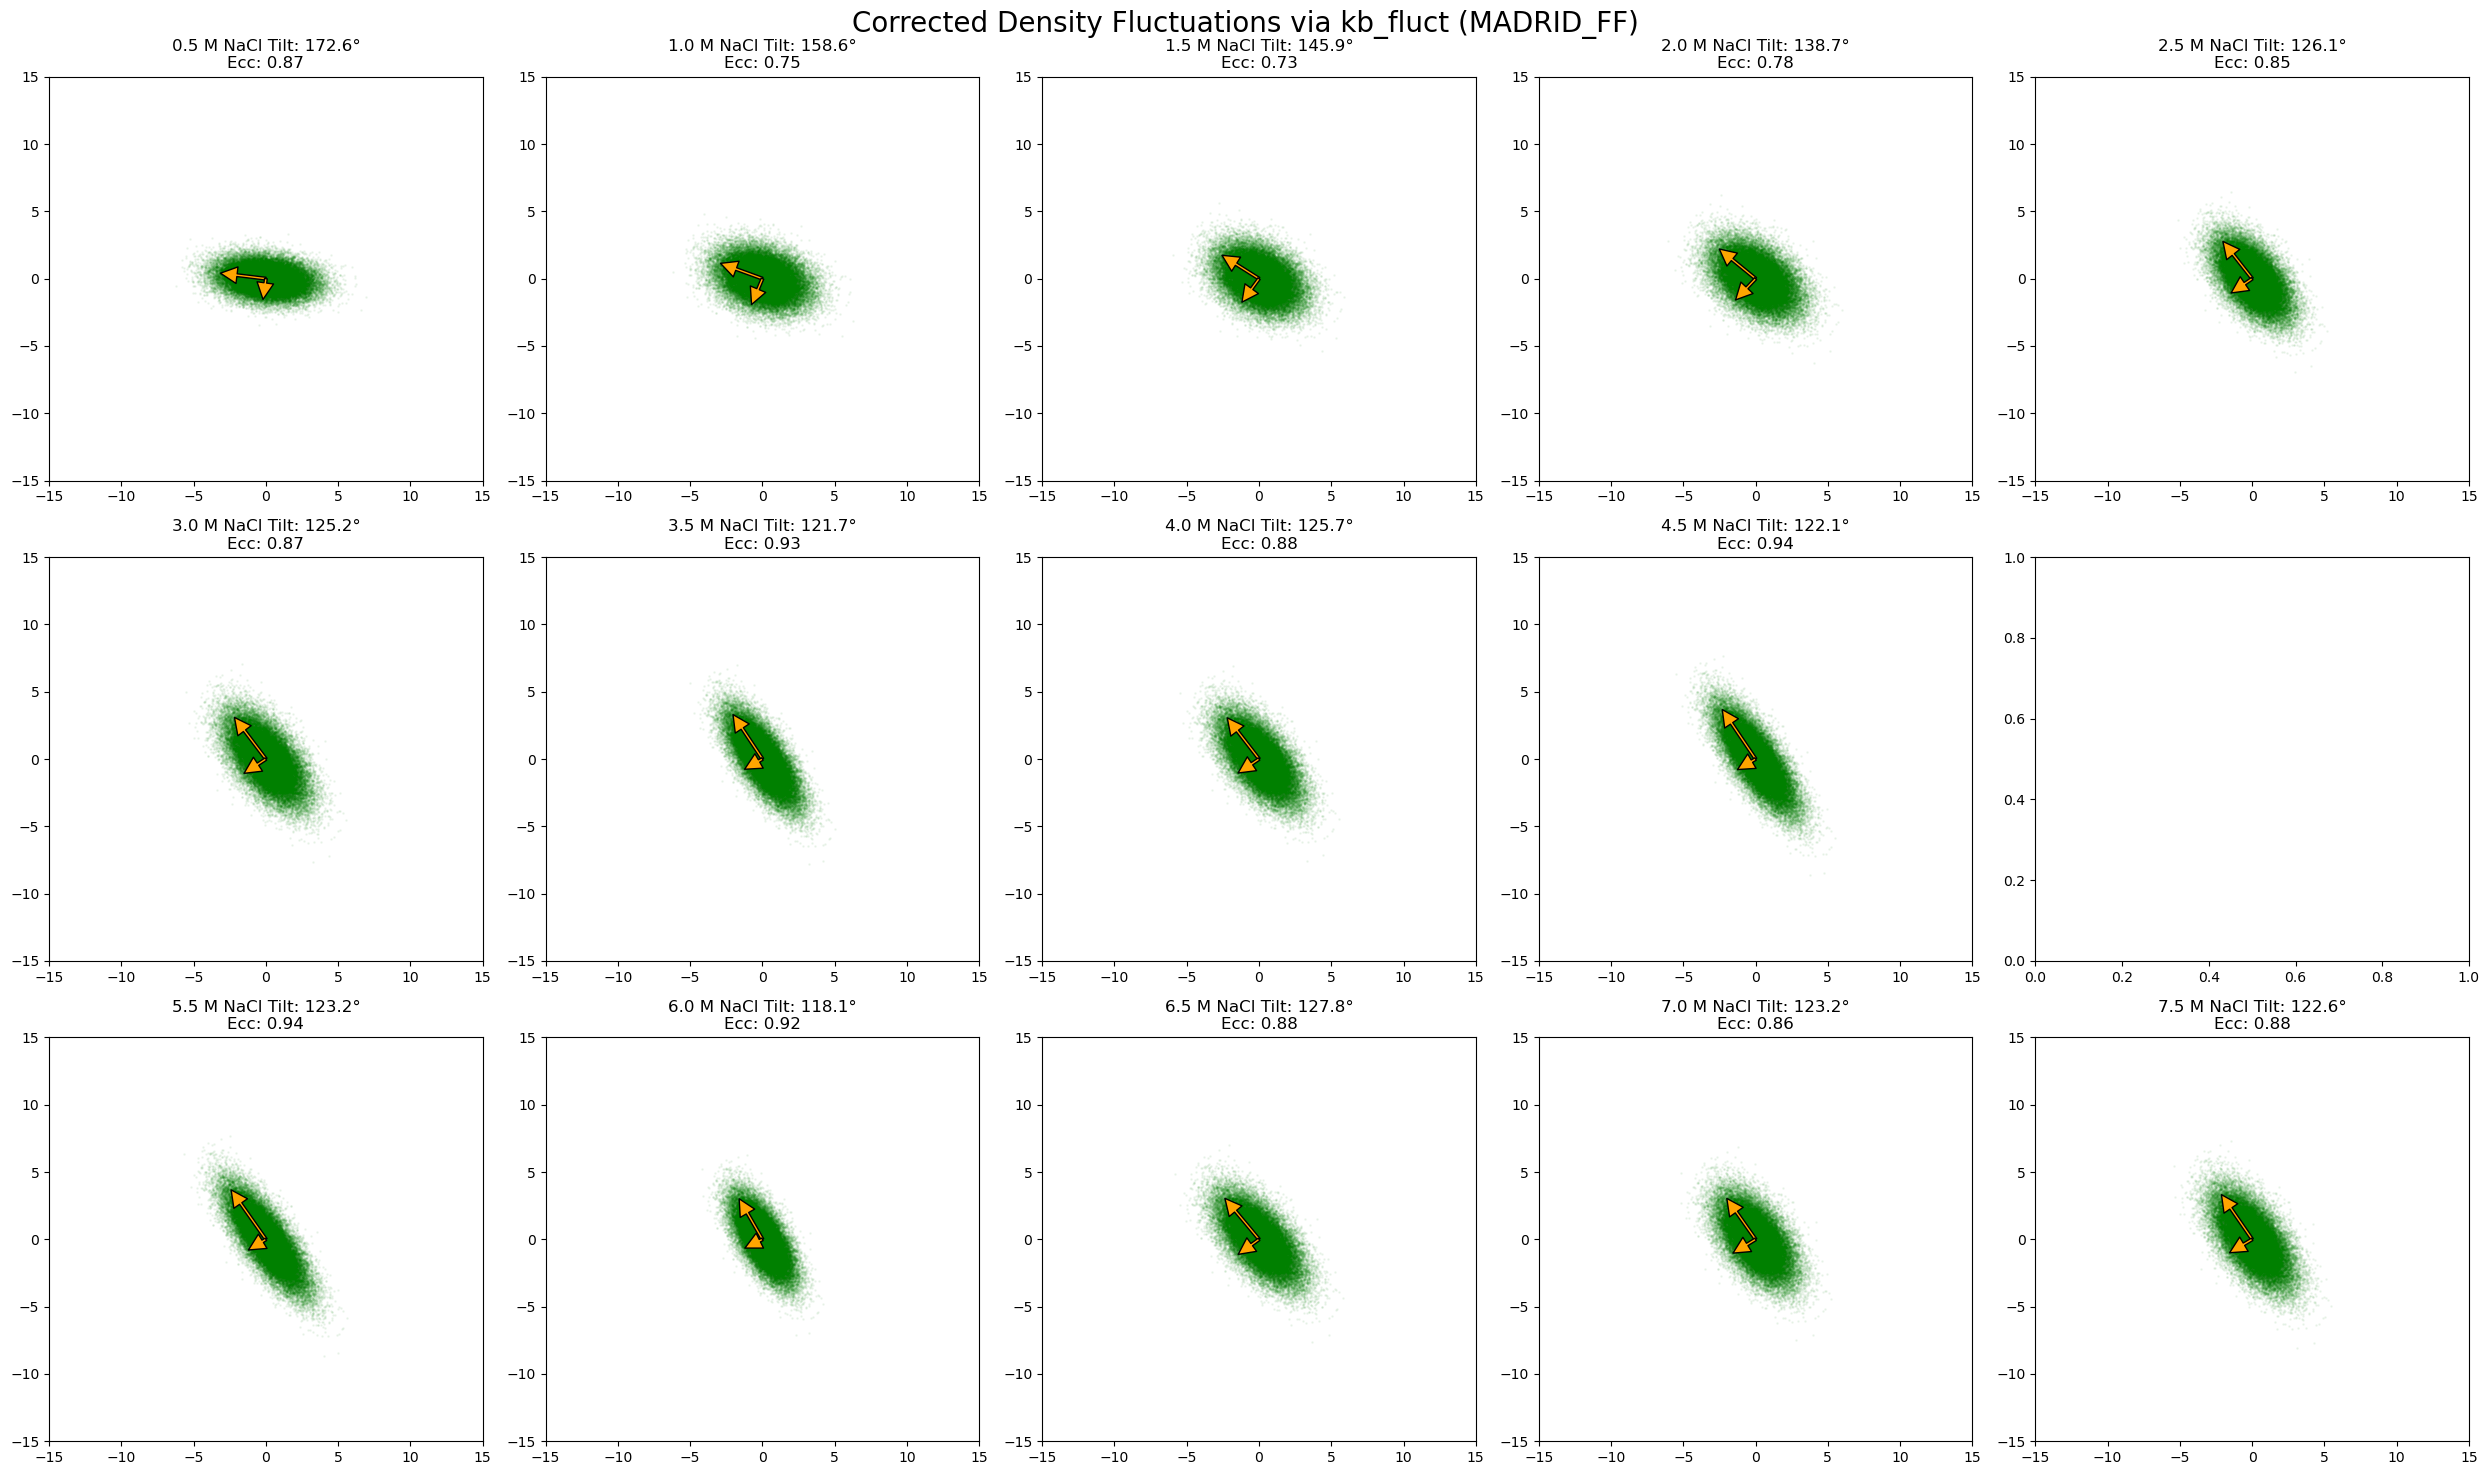

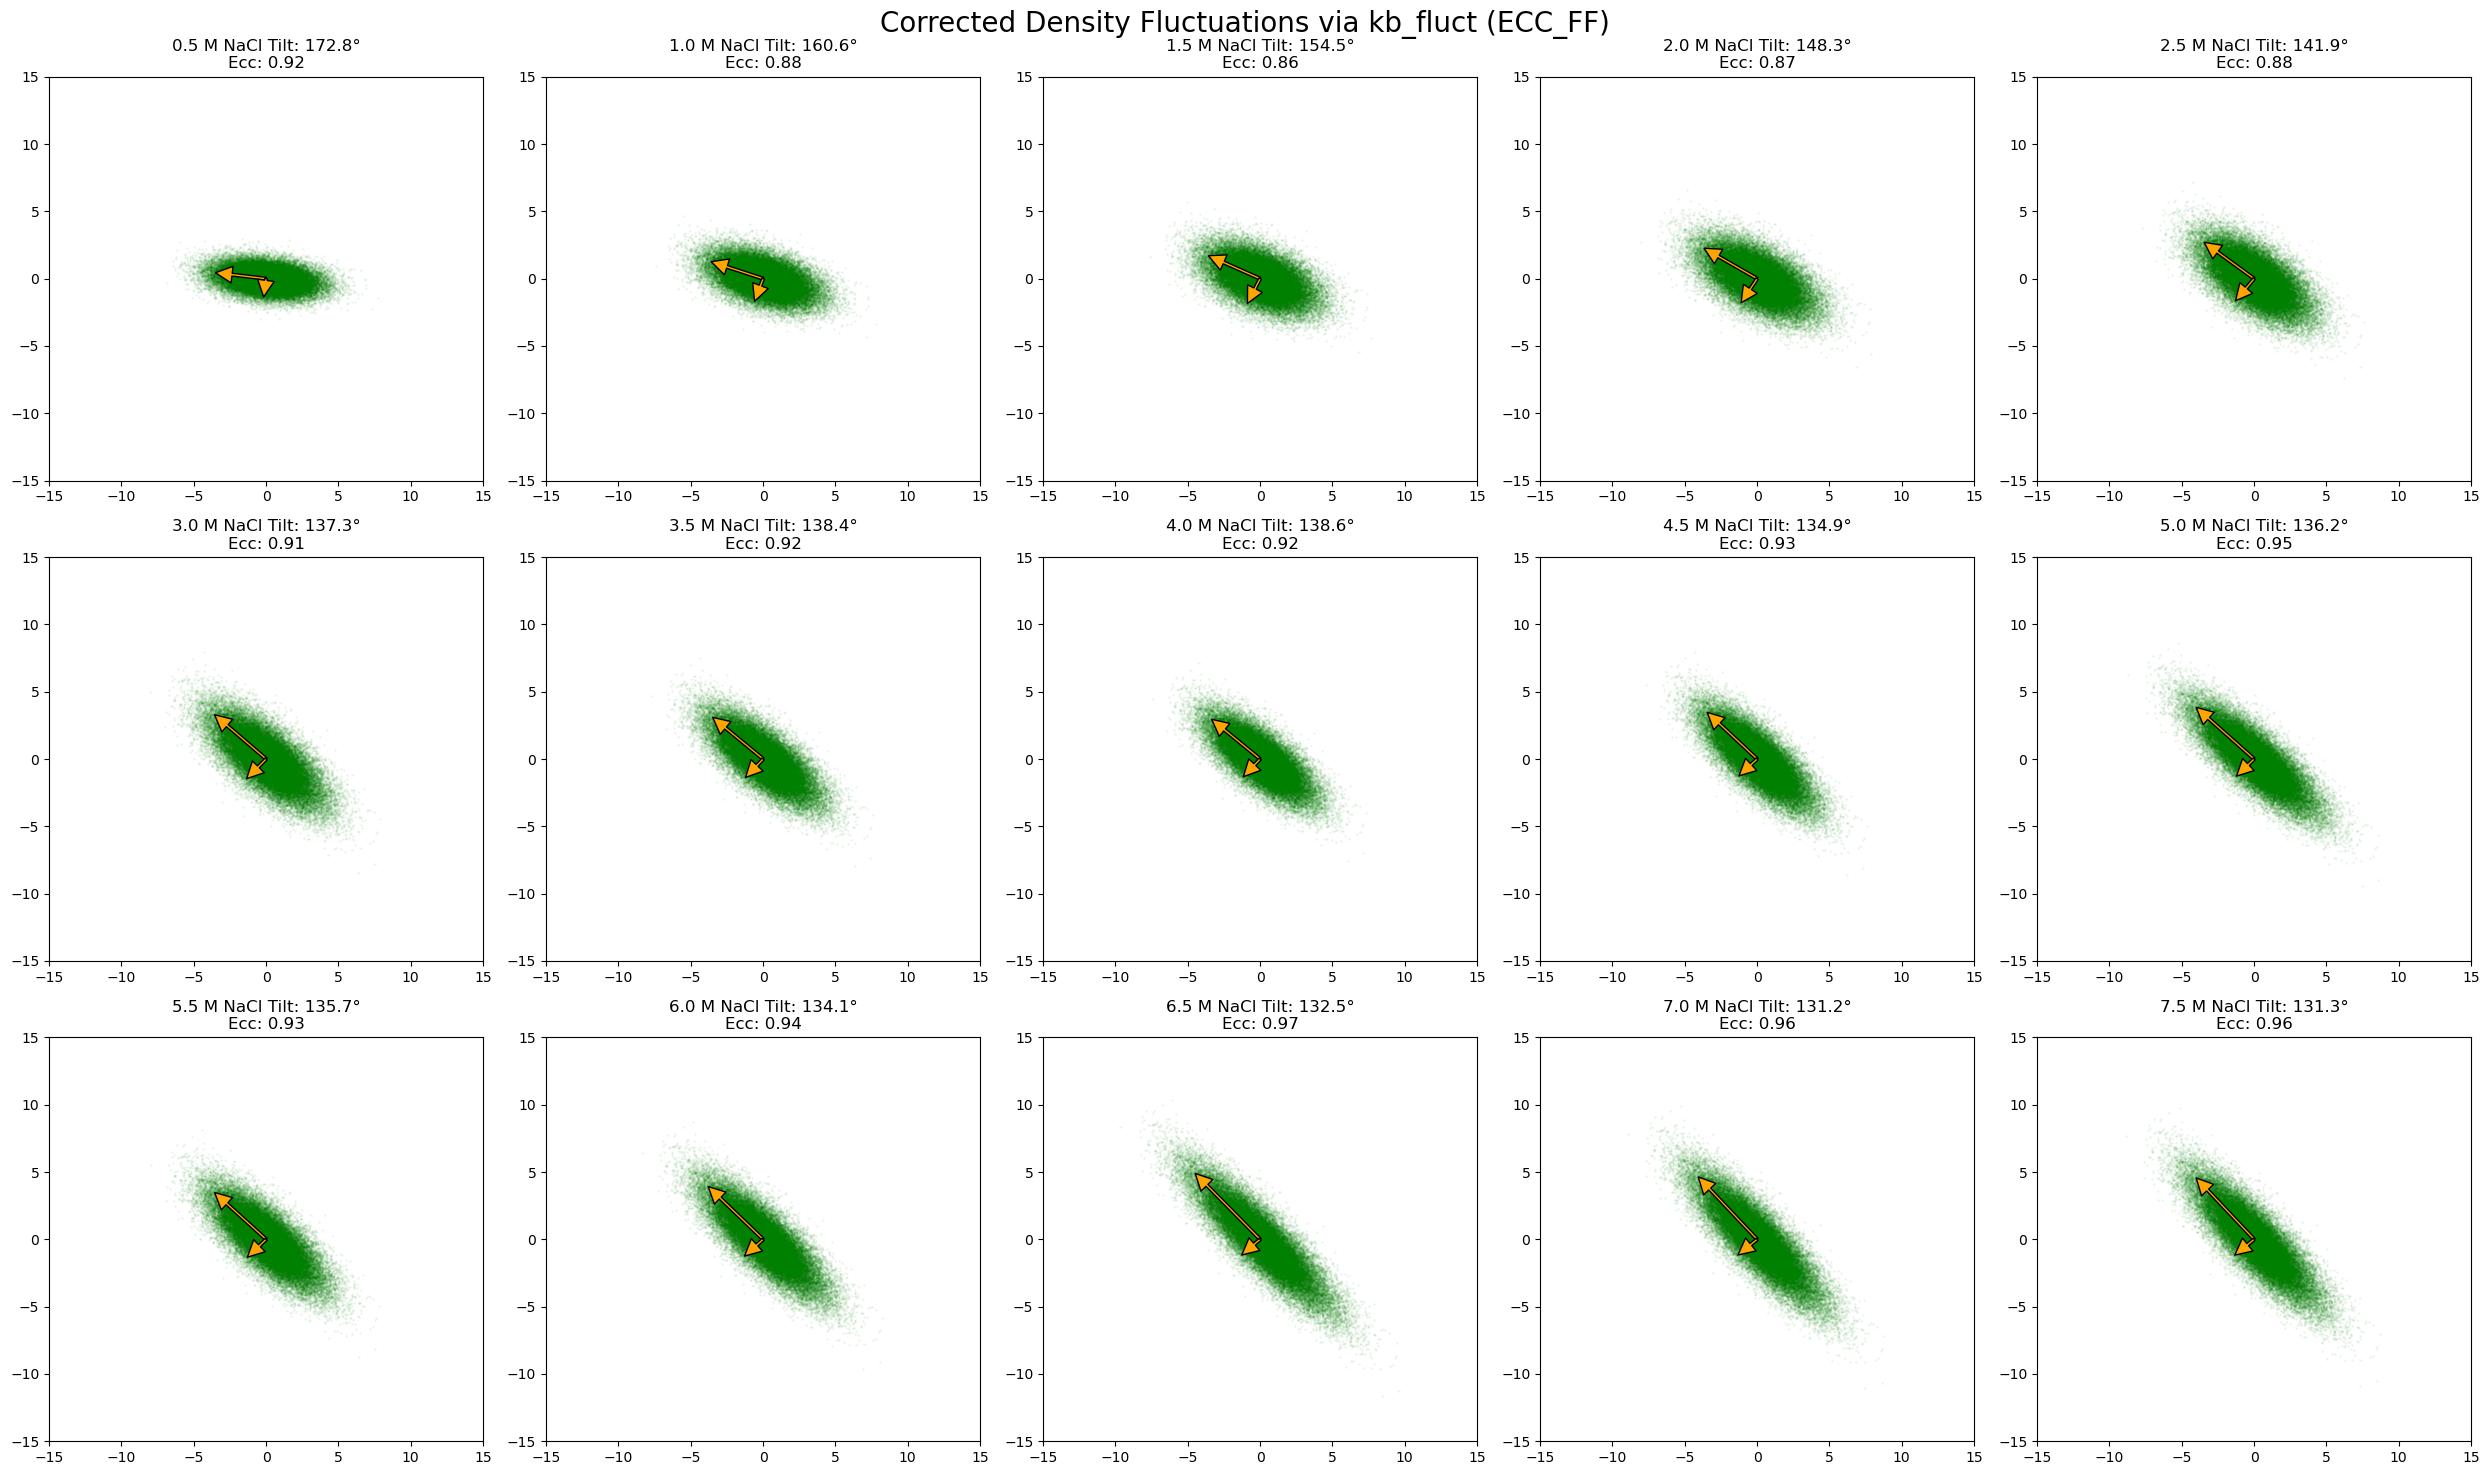

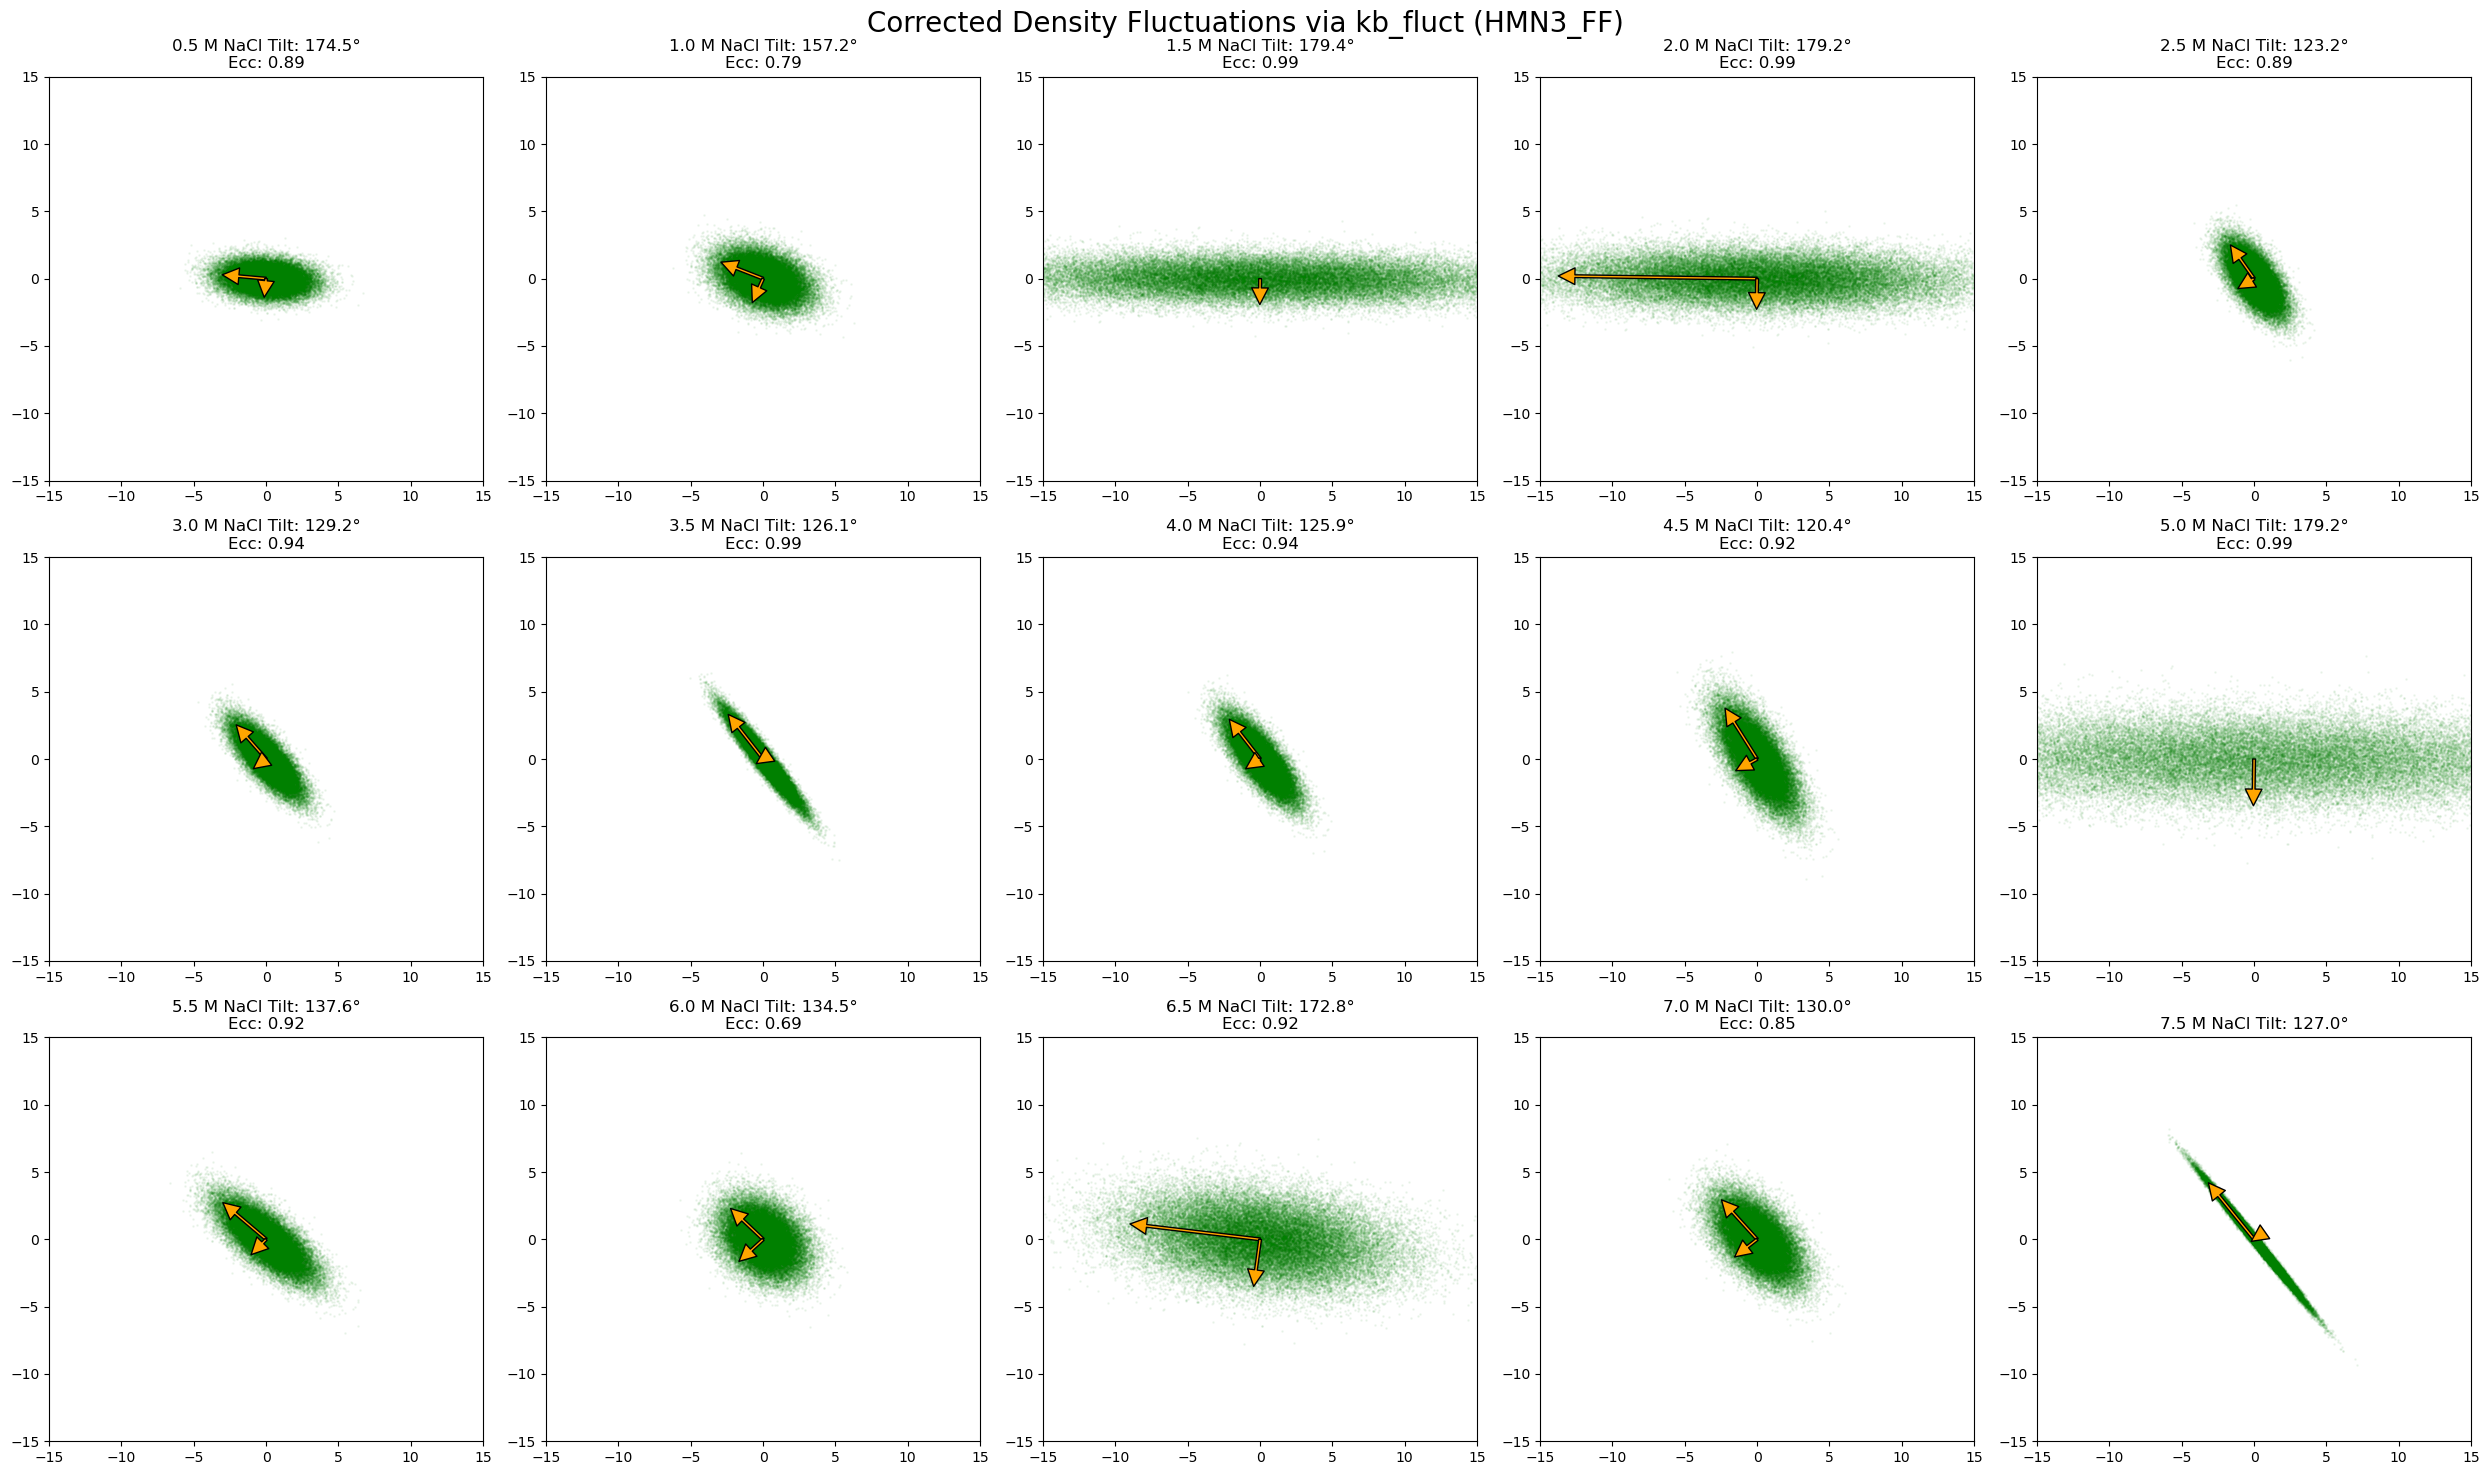

In [2]:
from kb_fluct import GangulyCorrection

for ff in force_fields:
    fig, axes = plt.subplots(3, 5, figsize=(25, 15))
    axes = axes.flatten()

    for i, conc in enumerate(concs):
        ax = axes[i]
        base_dir = f"../../data/solution_phase/{ff}/{conc}M_large_box/prod_npt/analysis"
        
        ww_files = glob.glob(f"{base_dir}/rdf/rdf_OW_OW*.xvg") + glob.glob(f"{base_dir}/rdf/rdf_water_water*.xvg")
        iw_files = glob.glob(f"{base_dir}/rdf/rdf_ion_water*.xvg")
        ii_files = glob.glob(f"{base_dir}/rdf/rdf_ion_ion*.xvg")
        vol_files = glob.glob(f"{base_dir}/avg_vol/avg_vol*.xvg")
        
        if not (ww_files and iw_files and ii_files and vol_files):
            ax.set_xticks([]); ax.set_yticks([])
            continue
            
        try:
            r, g11_raw = read_xvg(ww_files[0])
            _, g12_raw = read_xvg(iw_files[0])
            _, g22_raw = read_xvg(ii_files[0])
            _, vol = read_xvg(vol_files[0])
        except Exception:
            continue
            
        avg_V = np.mean(vol)
        N_w, N_i = 1110.0, conc * 40.0
        rho_1, rho_2 = N_w / avg_V, N_i / avg_V
        
        g11_corr = GangulyCorrection(N=N_w, V=avg_V, is_self_pair=True).transform(r, g11_raw)
        g12_corr = GangulyCorrection(N=N_w, V=avg_V, is_self_pair=False).transform(r, g12_raw)
        g22_corr = GangulyCorrection(N=N_i, V=avg_V, is_self_pair=True).transform(r, g22_raw)
        
        fluct = FluctuationMatrix(rho_1, rho_2).fit(
            G11=calc_kbi(r, g11_corr), G22=calc_kbi(r, g22_corr), G12=calc_kbi(r, g12_corr)
        )
        S_mat = fluct.results['S_matrix']
        analyzer = EllipseAnalyzer().fit(S_mat)
        
        # DRAW ARROWS UNCONDITIONALLY FIRST
        for j in range(2):
            vec = analyzer.results['eigenvectors'][:, j] * np.sqrt(np.abs(analyzer.results['eigenvalues'][j])) * 2
            ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(facecolor="orange", width=2))
        
        title = f"{conc} M NaCl Tilt: {analyzer.results['tilt_angle_degrees']:.1f}°"
        if not np.isnan(analyzer.results['eccentricity']):
            title += f"\nEcc: {analyzer.results['eccentricity']:.2f}"
        
        ax.set_title(title, fontsize=12)
        ax.set_xlim(-15, 15); ax.set_ylim(-15, 15)
        
        # DRAW POINTS
        np.random.seed(42)
        try:
            points = np.random.multivariate_normal([0, 0], S_mat, 50000)
            ax.scatter(points[:, 0], points[:, 1], s=1, color="green", alpha=0.05)
        except ValueError:
            ax.set_title(title + "\n(Not PSD)", fontsize=12)

    plt.suptitle(f"Corrected Density Fluctuations via kb_fluct ({ff.upper()})", fontsize=20)
    plt.tight_layout()
    plt.savefig(f"fluctuation_corrected_{ff}.png", dpi=300, bbox_inches='tight', facecolor='white')
#plt.close()



In [3]:
from kb_fluct import summarize_results
from IPython.display import display

# Summarize all parameters into a nice pandas DataFrame
summary_df = summarize_results(fluct, analyzer)
display(summary_df)

,Analyzer,S11,S22,S12,S_matrix,is_positive_definite,eigenvalues_comp_1,eigenvalues_comp_2,eigenvectors,tilt_angle_degrees,eccentricity,area
0,FluctuationMatrix,2.4892,4.4085,-3.3287,<matrix>,-,-,-,-,-,-,-
1,EllipseAnalyzer,-,-,-,-,False,6.9132,-0.0154,<matrix>,126.959,-,-
